In [5]:
%pip install 'stable-baselines3[extra]'
%pip install sb3-contrib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import gymnasium as gym
from stable_baselines3.common.monitor import Monitor
from stable_baselines3 import PPO

from blackjack_env.wrappers import ShiftWrapper, SafeV1ActionWrapper

log_dir = os.path.abspath(f"../results/sb3_blackjack_{int(time.time())}")
os.makedirs(log_dir, exist_ok=True)

env = gym.make("Blackjack4game-v1", render_mode=None)
env = ShiftWrapper(env)
env = SafeV1ActionWrapper(env)
env = Monitor(env, filename=os.path.join(log_dir, "monitor.csv"))

model = PPO("MultiInputPolicy", env, verbose=1, tensorboard_log=log_dir)

<frozen importlib._bootstrap>:491: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
/home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/.venv/lib/python3.14/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/.venv/lib/python3.14/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, 

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3.25     |
|    ep_rew_mean     | -0.135   |
| time/              |          |
|    fps             | 1007     |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 3.15        |
|    ep_rew_mean          | -0.121      |
| time/                   |             |
|    fps                  | 774         |
|    iterations           | 2           |
|    time_elapsed         | 5           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009084335 |
|    clip_fraction        | 0.102       |
|    clip_range           | 0.2         |
|    entropy_loss  

/home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/.venv/lib/python3.14/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/.venv/lib/python3.14/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [2]:
model.learn(total_timesteps=50_000)

Logging to /home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/blackjack_gym/notebooks/results/sb3_blackjack_1779719869/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3.33     |
|    ep_rew_mean     | -0.29    |
| time/              |          |
|    fps             | 1157     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 3.15        |
|    ep_rew_mean          | -0.0693     |
| time/                   |             |
|    fps                  | 887         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011976121 |
|    clip_fraction        | 0.12      

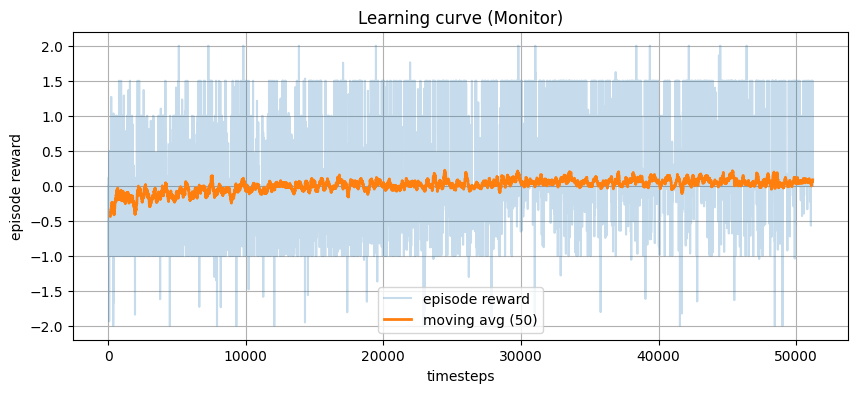

log_dir: /home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/blackjack_gym/notebooks/results/sb3_blackjack_1779719869


In [3]:
from stable_baselines3.common.results_plotter import load_results, ts2xy


def moving_average(x, w=50):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")


results = load_results(log_dir)
x, y = ts2xy(results, "timesteps")  # x=timesteps, y=episode reward

y_smooth = moving_average(y, w=50)
x_smooth = x[len(x) - len(y_smooth) :]

plt.figure(figsize=(10, 4))
plt.plot(x, y, alpha=0.25, label="episode reward")
plt.plot(x_smooth, y_smooth, linewidth=2, label="moving avg (50)")
plt.xlabel("timesteps")
plt.ylabel("episode reward")
plt.title("Learning curve (Monitor)")
plt.legend()
plt.grid(True)
plt.show()

print("log_dir:", log_dir)